# 13 — Data Ingestion Pipeline
## RentSignal — Unified Data Architecture (Phase 1)

**Goal:** Ingest the Apify 2026 scrape (8,335 records) into the unified relational schema defined in `docs/technical/DATA-ARCHITECTURE.md`.

**Tables produced:**
| Table | Description | File |
|-------|-------------|------|
| `units` | Master registry — one row per physical apartment | `data/processed/units.parquet` |
| `listings` | Price panel — one row per (unit × date) observation | `data/processed/listings.parquet` |

**Pipeline functions:** `data/pipelines/ingestion.py` (reusable for future scrapes)

**Input:** `data/raw/scraping/dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json` (8,335 records, 397 MB)

> **Note:** The small Mar 17 file (568 records) is a test scrape (first page only) — overlaps with the big file. We skip it.

In [1]:
import sys, json, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path so we can import data.pipelines
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from data.pipelines.ingestion import (
    extract_apify_record, extract_sections,
    convert_types, derive_features, apply_quality_filters,
    deduplicate, assign_unit_ids,
    build_units_table, build_listings_table,
    ingest_apify,
)

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw' / 'scraping'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'

# Use the big scrape only (Mar 18, 8335 records)
RAW_FILE = RAW_DIR / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
assert RAW_FILE.exists(), f'File not found: {RAW_FILE}'
print(f'Input: {RAW_FILE.name} ({RAW_FILE.stat().st_size / 1e6:.0f} MB)')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

Input: dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json (398 MB)


## 1. Load & Extract Raw JSON

Each Apify record has:
- `adTargetingParameters` — primary source (54 flat fields)
- `basicInfo.address` — lat/lon coordinates (61% coverage)
- `sections` — fallback for yearConstructed + thermalChar

In [2]:
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)

print(f'Raw records loaded: {len(raw):,}')
print(f'Top-level keys: {list(raw[0].keys())}')

# Extract flat records + section fallbacks
df = pd.DataFrame([extract_apify_record(r) for r in raw])
sec = pd.DataFrame([extract_sections(r) for r in raw])
df = pd.concat([df, sec], axis=1)

print(f'\nExtracted DataFrame: {df.shape}')
print(f'Columns: {list(df.columns)}')

Raw records loaded: 8,335
Top-level keys: ['header', 'sections', 'contact', 'tracking', 'adTargetingParameters', 'basicInfo', 'scrapedAt', 'url']

Extracted DataFrame: (8335, 33)
Columns: ['scout_id', 'scraped_at', 'url', 'baseRent', 'totalRent', 'serviceCharge', 'heatingCosts', 'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'plz', 'regio3', 'regio4', 'street', 'street_plain', 'house_number', 'lat', 'lon', 'immotype', 'thermalChar_section', 'yearConstructed_section']


In [3]:
# Quick look at raw coverage before any cleaning
print('=== Raw Field Coverage ===')
for col in df.columns:
    non_null = df[col].notna().sum()
    if df[col].dtype == object:
        non_empty = (df[col].fillna('').astype(str).str.strip() != '').sum()
        non_noinfo = ((df[col].fillna('') != 'no_information') & (df[col].fillna('') != '')).sum()
        print(f'  {col:<25} {non_null:>6} non-null, {non_noinfo:>6} meaningful')
    else:
        print(f'  {col:<25} {non_null:>6} non-null')

=== Raw Field Coverage ===
  scout_id                    8335 non-null
  scraped_at                  8335 non-null
  url                         8335 non-null
  baseRent                    8335 non-null
  totalRent                   5766 non-null
  serviceCharge               4552 non-null
  heatingCosts                1410 non-null
  livingSpace                 8335 non-null
  noRooms                     8335 non-null
  yearConstructed             2615 non-null
  floor                       4444 non-null
  numberOfFloors              2731 non-null
  balcony                     8335 non-null
  hasKitchen                  8335 non-null
  lift                        8335 non-null
  cellar                      8335 non-null
  garden                      8335 non-null
  newlyConst                  8335 non-null
  condition                   8335 non-null
  interiorQual                8335 non-null
  typeOfFlat                  8335 non-null
  heatingType                 8335 non-null
  plz

## 2. Type Conversions & Feature Derivation

- Numeric casting (baseRent, livingSpace, etc.)
- Boolean mapping (y/n → True/False)
- Categorical cleaning (no_information → unknown)
- Derived features: `rent_sqm`, `sqm_per_room`, `building_era`, `bezirk`
- Street name HTML decoding (e.g. `&szlig;` → `ß`)
- Building era uses **canonical categories** matching the model encoder: `pre_1918`, `1919_1949`, ..., `2015_plus`

In [4]:
df = convert_types(df)
df = derive_features(df)

print(f'Shape after derivation: {df.shape}')
print(f'\nrent_sqm range: {df["rent_sqm"].min():.2f} – {df["rent_sqm"].max():.2f} €/m²')
print(f'rent_sqm mean:  {df["rent_sqm"].mean():.2f} €/m²')
print(f'\nBuilding era distribution:')
print(df['building_era'].value_counts().to_string())
print(f'\nBezirk distribution (top 15):')
print(df['bezirk'].value_counts().head(15).to_string())

Shape after derivation: (8335, 37)

rent_sqm range: 0.01 – 8571.43 €/m²
rent_sqm mean:  18.72 €/m²

Building era distribution:
building_era
unknown      5720
2015_plus    1371
pre_1918      541
1991_2002     190
1973_1990     116
1950_1964     114
1919_1949      98
2003_2014      97
1965_1972      88

Bezirk distribution (top 15):
bezirk
Neukölln          677
Berg              559
Mitte             555
Friedrichshain    553
Charlottenburg    472
Wedding           443
Köpenick          414
Schöneberg        403
Tiergarten        400
Kreuzberg         398
Wilmersdorf       389
Spandau           380
Lichtenberg       378
Reinickendorf     373
Treptow           361


In [5]:
# Verify bezirk mapping covers the 23 old Bezirke used by the model
kaggle_bezirke = set(pd.read_parquet(PROC_DIR / 'listings_clean.parquet', columns=['bezirk'])['bezirk'].unique())
apify_bezirke = set(df['bezirk'].unique())

print(f'Kaggle bezirke ({len(kaggle_bezirke)}): {sorted(kaggle_bezirke)}')
print(f'\nApify bezirke ({len(apify_bezirke)}):  {sorted(apify_bezirke)}')
print(f'\nIn Kaggle but not Apify: {sorted(kaggle_bezirke - apify_bezirke)}')
print(f'In Apify but not Kaggle: {sorted(apify_bezirke - kaggle_bezirke)}')

Kaggle bezirke (23): ['Berg', 'Charlottenburg', 'Friedrichshain', 'Hellersdorf', 'Hohenschönhausen', 'Kreuzberg', 'Köpenick', 'Lichtenberg', 'Marzahn', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf', 'Schöneberg', 'Spandau', 'Steglitz', 'Tempelhof', 'Tiergarten', 'Treptow', 'Wedding', 'Weißensee', 'Wilmersdorf', 'Zehlendorf']

Apify bezirke (24):  ['Berg', 'Charlottenburg', 'Friedrichshain', 'Hellersdorf', 'Hohenschönhausen', 'Kreuzberg', 'Köpenick', 'Lichtenberg', 'Marzahn', 'Mitte', 'Neukölln', 'Pankow', 'Reinickendorf', 'Schöneberg', 'Spandau', 'Steglitz', 'Tempelhof', 'Tiergarten', 'Treptow', 'Wedding', 'Weißensee', 'Wilmersdorf', 'Zehlendorf', 'unknown']

In Kaggle but not Apify: []
In Apify but not Kaggle: ['unknown']


## 3. Quality Filters & Deduplication

In [6]:
df = apply_quality_filters(df)
df = deduplicate(df)

Quality filter: 8335 → 8258 (77 dropped, 0.9%)
Deduplication: removed 2 duplicate scout_ids


## 4. Assign IDs & Build Relational Tables

**`units` table:** One row per physical apartment with stable `RS-XXXXXX` ID.  
**`listings` table:** One row per (unit × date) price observation with `AP-XXXXXX` listing ID.

In [7]:
# Assign unit IDs and listing IDs
df['source'] = 'apify_2026_03'
df = assign_unit_ids(df, start_from=1)
df['observed_date'] = pd.to_datetime(df['scraped_at'], errors='coerce').dt.date
df['listing_id'] = [f'AP-{i:06d}' for i in range(1, len(df) + 1)]

# Build the two relational tables
units = build_units_table(df)
listings = build_listings_table(df)

print(f'=== units table ===')
print(f'Shape: {units.shape}')
print(f'Columns: {list(units.columns)}')
print(f'\n=== listings table ===')
print(f'Shape: {listings.shape}')
print(f'Columns: {list(listings.columns)}')

=== units table ===
Shape: (8256, 29)
Columns: ['unit_id', 'scout_id', 'source', 'plz', 'bezirk', 'neighborhood', 'street', 'street_plain', 'house_number', 'lat', 'lon', 'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 'thermalChar', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'building_era', 'sqm_per_room']

=== listings table ===
Shape: (8256, 8)
Columns: ['listing_id', 'unit_id', 'observed_date', 'source', 'baseRent', 'totalRent', 'serviceCharge', 'rent_sqm']


In [8]:
# Preview units table
units.head(5)

,unit_id,scout_id,source,plz,bezirk,neighborhood,street,street_plain,house_number,lat,...,lift,cellar,garden,newlyConst,condition,interiorQual,typeOfFlat,heatingType,building_era,sqm_per_room
0,RS-000001,166409657,apify_2026_03,10961,Kreuzberg,Kreuzberg,NaN,NaN,NaN,NaN,...,False,False,False,False,well_kept,sophisticated,apartment,unknown,unknown,40.00
1,RS-000002,132996603,apify_2026_03,13469,Reinickendorf,Waidmannslust,Schluchseestr.,Schluchseestr.,57,52.60728,...,False,True,False,False,unknown,unknown,ground_floor,district_heating,1965_1972,32.72
2,RS-000003,166410091,apify_2026_03,10247,Friedrichshain,Friedrichshain,NaN,NaN,NaN,NaN,...,True,True,True,False,unknown,sophisticated,unknown,unknown,unknown,32.50
3,RS-000004,166409663,apify_2026_03,12683,Marzahn,Biesdorf,Alt-Biesdorf,Alt-Biesdorf,49A,52.50553,...,True,False,False,False,mint_condition,unknown,apartment,environmental_thermal_energy,2015_plus,20.00
4,RS-000005,166409654,apify_2026_03,10243,Friedrichshain,Friedrichshain,Warschauer Straße,Warschauer Straße,6,52.51466,...,True,False,True,False,modernized,normal,unknown,unknown,unknown,29.00


In [9]:
# Preview listings table
listings.head(5)

,listing_id,unit_id,observed_date,source,baseRent,totalRent,serviceCharge,rent_sqm
0,AP-000001,RS-000001,2026-03-18,apify_2026_03,900.00,1383.00,483.0,11.250000
1,AP-000002,RS-000002,2026-03-18,apify_2026_03,516.85,785.85,158.0,7.898075
2,AP-000003,RS-000003,2026-03-18,apify_2026_03,1204.58,1496.58,165.0,18.532000
3,AP-000004,RS-000004,2026-03-18,apify_2026_03,1196.00,NaN,84.0,19.933333
4,AP-000005,RS-000005,2026-03-18,apify_2026_03,1150.00,1333.00,183.0,39.655172


## 5. Coordinate Coverage

Key question: how many units already have lat/lon from the Apify scrape vs. needing geocoding?

In [10]:
has_coords = units['lat'].notna() & units['lon'].notna()
has_street = units['street'].notna() & (units['street'] != '')
has_house  = units['house_number'].notna() & (units['house_number'] != '')

print(f'=== Coordinate Coverage (units table) ===')
print(f'Total units:           {len(units):,}')
print(f'Has lat/lon:           {has_coords.sum():,} ({100*has_coords.mean():.1f}%)')
print(f'Has street name:       {has_street.sum():,} ({100*has_street.mean():.1f}%)')
print(f'Has house number:      {has_house.sum():,} ({100*has_house.mean():.1f}%)')
print(f'Has street+house:      {(has_street & has_house).sum():,}')
print(f'Missing coords:        {(~has_coords).sum():,}  ← need geocoding')
print(f'  of which have street+house: {(~has_coords & has_street & has_house).sum():,}  ← geocodable')
print(f'  of which have nothing:      {(~has_coords & ~has_street).sum():,}  ← PLZ-only fallback')

=== Coordinate Coverage (units table) ===
Total units:           8,256
Has lat/lon:           5,081 (61.5%)
Has street name:       5,092 (61.7%)
Has house number:      5,092 (61.7%)
Has street+house:      5,092
Missing coords:        3,175  ← need geocoding
  of which have street+house: 11  ← geocodable
  of which have nothing:      3,164  ← PLZ-only fallback


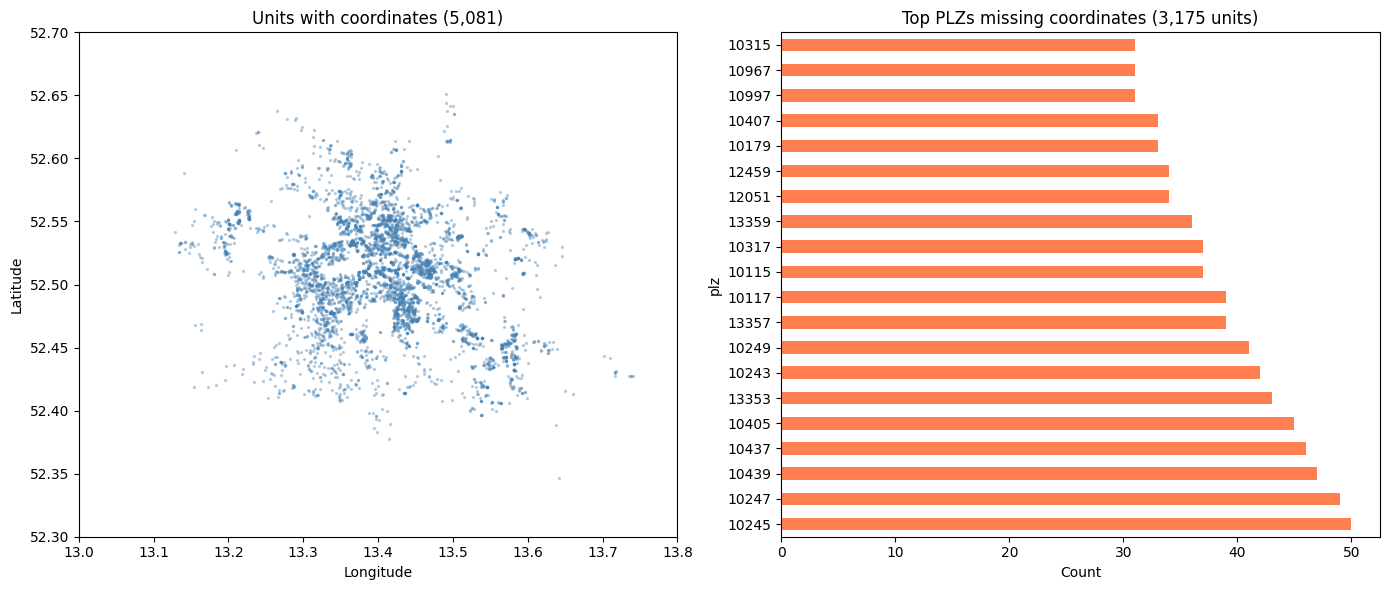

In [11]:
# Map: units with coords vs without
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter of units with coords
ax = axes[0]
coords = units[has_coords]
ax.scatter(coords['lon'], coords['lat'], s=2, alpha=0.3, c='steelblue')
ax.set_title(f'Units with coordinates ({len(coords):,})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(13.0, 13.8)
ax.set_ylim(52.3, 52.7)

# Right: PLZ distribution of units WITHOUT coords
ax = axes[1]
no_coords = units[~has_coords]
no_coords['plz'].value_counts().head(20).plot(kind='barh', ax=ax, color='coral')
ax.set_title(f'Top PLZs missing coordinates ({len(no_coords):,} units)')
ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

## 6. Feature Coverage & Quality Report

In [12]:
features = ['livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors',
            'thermalChar', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden',
            'newlyConst', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType',
            'building_era', 'bezirk', 'plz', 'lat', 'lon', 'street', 'house_number']

print('=== Feature Coverage Report ===')
print(f'{"Feature":<22} {"Coverage":>8}  {"Status":>6}')
print('-' * 42)
for col in features:
    if col not in units.columns:
        print(f'  {col:<22} {"MISSING":>8}  {"ERR":>6}')
        continue
    if units[col].dtype == bool:
        pct = 100.0
    elif units[col].dtype == object:
        pct = ((units[col].notna()) & (units[col] != 'unknown') & (units[col] != '')).mean() * 100
    else:
        pct = units[col].notna().mean() * 100
    status = 'OK' if pct > 80 else 'WARN' if pct > 40 else 'LOW'
    bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f'  {col:<22} {pct:>6.1f}%  {status:>6}  {bar}')

=== Feature Coverage Report ===
Feature                Coverage  Status
------------------------------------------
  livingSpace             100.0%      OK  ████████████████████
  noRooms                 100.0%      OK  ████████████████████
  yearConstructed          31.5%     LOW  ██████░░░░░░░░░░░░░░
  floor                    53.8%    WARN  ██████████░░░░░░░░░░
  numberOfFloors           33.0%     LOW  ██████░░░░░░░░░░░░░░
  thermalChar              20.8%     LOW  ████░░░░░░░░░░░░░░░░
  balcony                 100.0%      OK  ████████████████████
  hasKitchen              100.0%      OK  ████████████████████
  lift                    100.0%      OK  ████████████████████
  cellar                  100.0%      OK  ████████████████████
  garden                  100.0%      OK  ████████████████████
  newlyConst              100.0%      OK  ████████████████████
  condition               100.0%      OK  ████████████████████
  interiorQual            100.0%      OK  ████████████████████
  t

## 7. EDA — Distributions & Comparison with Kaggle 2019

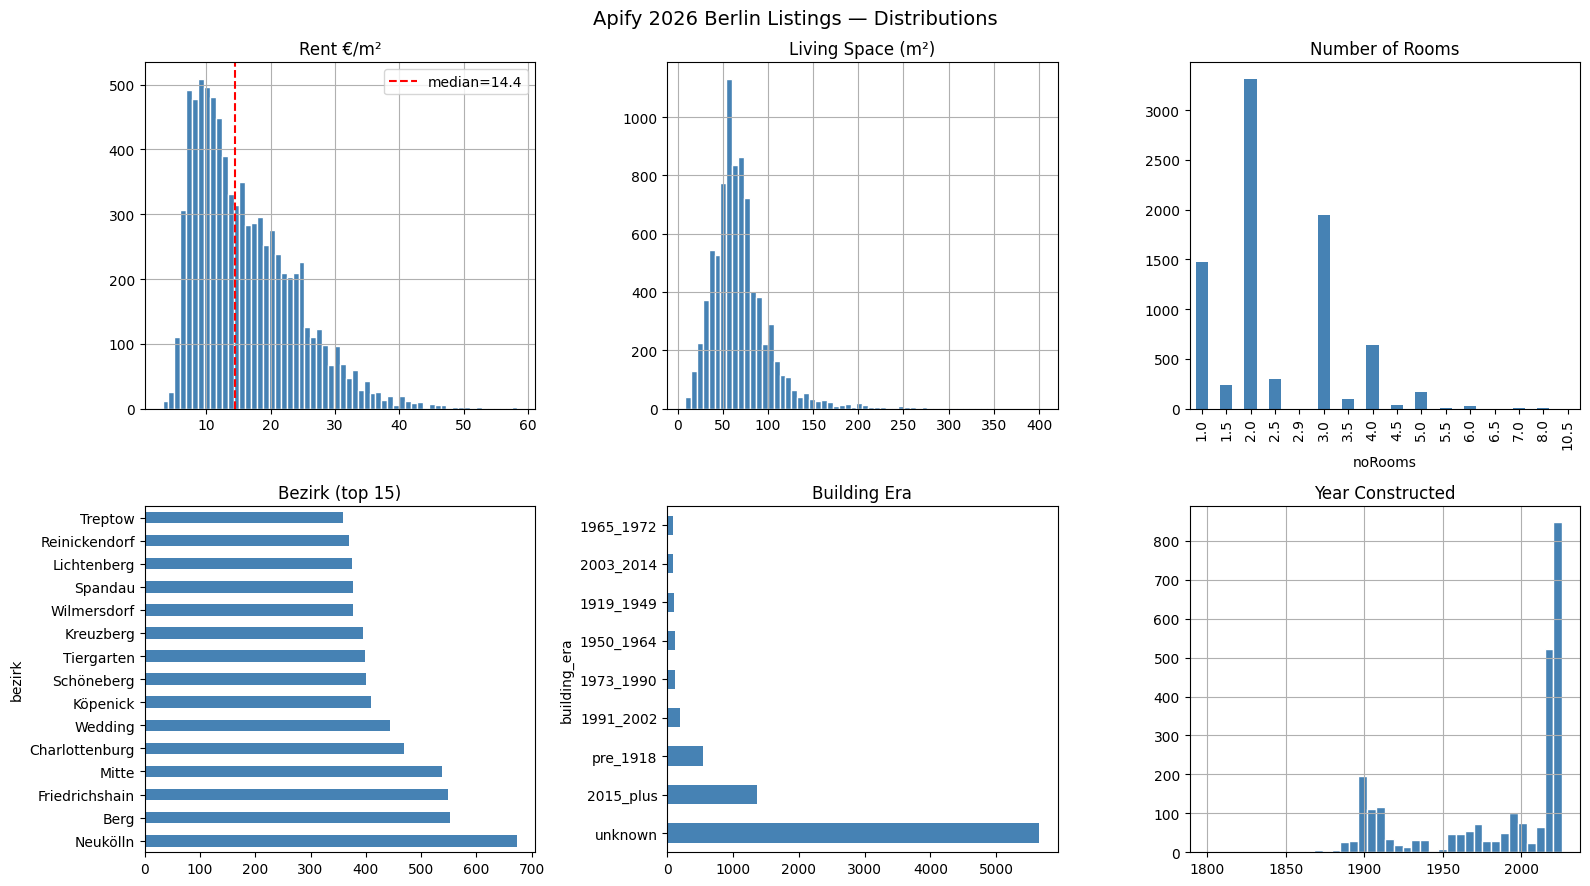

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Core distributions
listings_merged = listings.merge(units[['unit_id', 'livingSpace', 'noRooms', 'bezirk', 'building_era', 'yearConstructed']], on='unit_id')

listings_merged['rent_sqm'].hist(bins=60, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Rent €/m²')
axes[0,0].axvline(listings_merged['rent_sqm'].median(), color='red', ls='--', label=f'median={listings_merged["rent_sqm"].median():.1f}')
axes[0,0].legend()

listings_merged['livingSpace'].hist(bins=60, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Living Space (m²)')

listings_merged['noRooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Number of Rooms')

# Row 2: Categorical
listings_merged['bezirk'].value_counts().head(15).plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Bezirk (top 15)')

listings_merged['building_era'].value_counts().plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Building Era')

listings_merged['yearConstructed'].dropna().hist(bins=40, ax=axes[1,2], color='steelblue', edgecolor='white')
axes[1,2].set_title('Year Constructed')

plt.suptitle('Apify 2026 Berlin Listings — Distributions', fontsize=14)
plt.tight_layout()
plt.show()

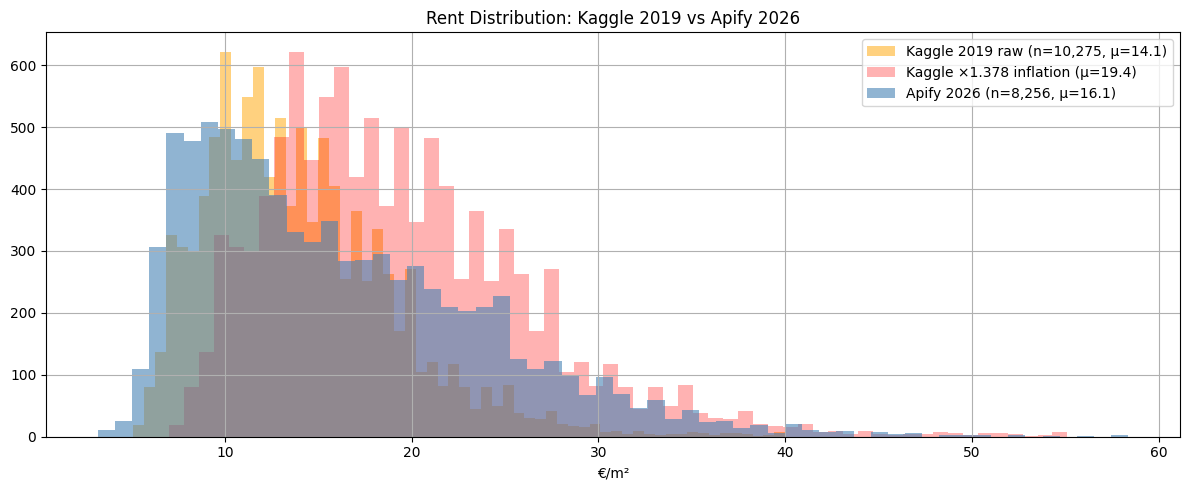

Kaggle 2019 mean rent:           14.06 €/m²
Kaggle 2019 × 1.378 (adj):       19.37 €/m²
Apify 2026 mean rent:            16.09 €/m²
Implied real inflation factor:   1.145


In [14]:
# Compare rent distributions: Kaggle 2019 vs Apify 2026
kaggle = pd.read_parquet(PROC_DIR / 'listings_clean.parquet')

fig, ax = plt.subplots(figsize=(12, 5))
kaggle['rent_sqm'].hist(bins=60, alpha=0.5, label=f'Kaggle 2019 raw (n={len(kaggle):,}, μ={kaggle["rent_sqm"].mean():.1f})', color='orange', ax=ax)
(kaggle['rent_sqm'] * 1.378).hist(bins=60, alpha=0.3, label=f'Kaggle ×1.378 inflation (μ={kaggle["rent_sqm"].mean()*1.378:.1f})', color='red', ax=ax)
listings_merged['rent_sqm'].hist(bins=60, alpha=0.6, label=f'Apify 2026 (n={len(listings_merged):,}, μ={listings_merged["rent_sqm"].mean():.1f})', color='steelblue', ax=ax)
ax.set_xlabel('€/m²')
ax.set_title('Rent Distribution: Kaggle 2019 vs Apify 2026')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Kaggle 2019 mean rent:           {kaggle["rent_sqm"].mean():.2f} €/m²')
print(f'Kaggle 2019 × 1.378 (adj):       {kaggle["rent_sqm"].mean() * 1.378:.2f} €/m²')
print(f'Apify 2026 mean rent:            {listings_merged["rent_sqm"].mean():.2f} €/m²')
print(f'Implied real inflation factor:   {listings_merged["rent_sqm"].mean() / kaggle["rent_sqm"].mean():.3f}')

## 8. Save Tables + Lineage

In [15]:
# Save units table
units_path = PROC_DIR / 'units.parquet'
units.to_parquet(units_path, index=False)
units_hash = hashlib.sha256(open(units_path, 'rb').read()).hexdigest()

# Save listings table
listings_path = PROC_DIR / 'listings.parquet'
listings.to_parquet(listings_path, index=False)
listings_hash = hashlib.sha256(open(listings_path, 'rb').read()).hexdigest()

print('=== Saved ===')
print(f'  {units_path.name}:    {len(units):,} rows, SHA-256: {units_hash[:16]}...')
print(f'  {listings_path.name}: {len(listings):,} rows, SHA-256: {listings_hash[:16]}...')
print()
print('=== Data Architecture Status ===')
print(f'  ✅ units table:      {len(units):,} physical apartments with RS-XXXXXX IDs')
print(f'  ✅ listings table:   {len(listings):,} price observations')
print(f'  ✅ lat/lon coverage: {has_coords.sum():,}/{len(units):,} ({100*has_coords.mean():.0f}%)')
print(f'  ⏳ spatial_plz:     190 PLZs (existing, needs re-linking)')
print(f'  ⏳ spatial_unit:    not yet computed (Phase 2-3)')
print()
print('=== Next Steps ===')
print('  Phase 2: Geocode missing coordinates (notebook 14)')
print('  Phase 3: Compute unit-level spatial features')
print('  Phase 4: Retrain XGBoost v4 on this data')

=== Saved ===
  units.parquet:    8,256 rows, SHA-256: a28436fe1007d106...
  listings.parquet: 8,256 rows, SHA-256: 0dc7e53abe361cc2...

=== Data Architecture Status ===
  ✅ units table:      8,256 physical apartments with RS-XXXXXX IDs
  ✅ listings table:   8,256 price observations
  ✅ lat/lon coverage: 5,081/8,256 (62%)
  ⏳ spatial_plz:     190 PLZs (existing, needs re-linking)
  ⏳ spatial_unit:    not yet computed (Phase 2-3)

=== Next Steps ===
  Phase 2: Geocode missing coordinates (notebook 14)
  Phase 3: Compute unit-level spatial features
  Phase 4: Retrain XGBoost v4 on this data


## 9. Sample Records — Spot Check

Quick sanity check on a few units to verify the pipeline output makes sense.

In [16]:
# Show a few complete records (units + listings joined)
sample = units.merge(listings, on='unit_id').sample(5, random_state=42)
display_cols = ['unit_id', 'listing_id', 'bezirk', 'plz', 'street', 'house_number',
                'lat', 'lon', 'livingSpace', 'noRooms', 'rent_sqm', 'baseRent',
                'building_era', 'condition', 'hasKitchen', 'balcony', 'observed_date']
sample[[c for c in display_cols if c in sample.columns]].T

,6064,518,5842,1558,1142
unit_id,RS-006065,RS-000519,RS-005843,RS-001559,RS-001143
listing_id,AP-006065,AP-000519,AP-005843,AP-001559,AP-001143
bezirk,Schöneberg,Spandau,Neukölln,Friedrichshain,Schöneberg
plz,10781,13585,12047,10245,12103
street,NaN,Schönwalder Straße,Nansenstraße 11,Stralauer Allee,In den Alboingärten
house_number,NaN,68,11,14A,25
lat,NaN,52.55121,52.48976,52.49791,52.46095
lon,NaN,13.19966,13.43118,13.46186,13.3638
livingSpace,131.22,106.0,70.0,52.0,64.0
noRooms,4.0,3.0,2.5,2.0,2.0


In [17]:
# Validate coordinate bounds (Berlin: lat 52.3-52.7, lon 13.0-13.8)
valid_coords = units[has_coords]
out_of_bounds = valid_coords[
    (valid_coords['lat'] < 52.3) | (valid_coords['lat'] > 52.7) |
    (valid_coords['lon'] < 13.0) | (valid_coords['lon'] > 13.8)
]
print(f'Coordinates out of Berlin bounds: {len(out_of_bounds)} / {len(valid_coords)}')
if len(out_of_bounds) > 0:
    print('  ⚠️  These should be investigated:')
    print(out_of_bounds[['unit_id', 'plz', 'bezirk', 'lat', 'lon']].head(10).to_string())

Coordinates out of Berlin bounds: 0 / 5081
